In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
import aerosandbox as asb
import pyfar as pf
from JobParameters import AerodynamicParameters, AcousticParameters
from Propeller import Propeller
from BPM import BPM

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=100, num_obs_times_per_rev=1000
)

In [ ]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [ ]:
r_observer = np.array([[0.1, 1.8, 0]])
propeller.run_compact_f1a(observer_positions=r_observer, use_GPU=True)

In [ ]:
third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(num_fractions=3, frequency_range=(20,20000))[0]

In [ ]:
bpm = BPM(propeller=propeller, frequencies=third_octave_freqs)
bpm.run_BPM()

In [ ]:
t = propeller.t[:, 0]
p_tone = propeller.p_tot[:, 0]

fs = 1 / (t[1] - t[0])
signal = pf.Signal(p_tone, fs, fft_norm='rms')
F1A_frequencies = signal.frequencies
F1A_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()

In [ ]:
F1A_spl_3oct = []
for fc in third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (propeller.freq[:, 0] >= f_low) & (propeller.freq[:, 0] < f_high)
    if np.any(mask):
        P_band = np.sum(10**(F1A_spl[mask] / 10))
        F1A_spl_3oct.append(10 * np.log10(P_band))
    else:
        F1A_spl_3oct.append(-np.inf)

F1A_spl_3oct = np.array(F1A_spl_3oct)

L_total = 10 * np.log10(
    10**(F1A_spl_3oct / 10) + 
    10**(bpm.SPL_LBL / 10) + 
    10**(bpm.SPL_TBL / 10) + 
    10**(bpm.SPL_TEB / 10) + 
    10**(bpm.SPL_TI / 10) + 
    10**(bpm.SPL_TIP / 10)
)

In [ ]:
def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_7000.pkl')
signal = pf.Signal(p_total, fs_total, fft_norm='rms')
meas_frequencies = signal.frequencies
meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()

In [ ]:
exp_spl_3oct = []
for fc in third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (meas_frequencies >= f_low) & (meas_frequencies < f_high)
    if np.any(mask):
        P_band = np.sum(10**(meas_spl[mask] / 10))
        exp_spl_3oct.append(10 * np.log10(P_band))
    else:
        exp_spl_3oct.append(-np.inf)

exp_spl_3oct = np.array(exp_spl_3oct)

In [ ]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra) + 2.0

In [ ]:
def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

In [ ]:
# Values for labels
ospl_f1a = calc_oaspl(F1A_spl_3oct, third_octave_freqs, weighted=False)
oaspl_f1a = calc_oaspl(F1A_spl_3oct, third_octave_freqs, weighted=True)

ospl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=False)
oaspl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=True)

ospl_tot = calc_oaspl(L_total, third_octave_freqs, weighted=False)
oaspl_tot = calc_oaspl(L_total, third_octave_freqs, weighted=True)

plt.figure(figsize=(11, 7))

# Components (keeping these simpler to avoid legend clutter)
plt.semilogx(third_octave_freqs, bpm.SPL_TBL, '--', alpha=0.6, label='TBL')
plt.semilogx(third_octave_freqs, bpm.SPL_LBL, '--', alpha=0.6, label='LBL')
plt.semilogx(third_octave_freqs, bpm.SPL_TEB, '--', alpha=0.6, label='TEB')
plt.semilogx(third_octave_freqs, bpm.SPL_TI, '--', alpha=0.6, label='TI')
plt.semilogx(third_octave_freqs, bpm.SPL_TIP, '--', alpha=0.6, label='TIP')
plt.semilogx(third_octave_freqs, F1A_spl_3oct, ':', label=f'F1A: {ospl_f1a:.1f} dB | {oaspl_f1a:.1f} dBA')

# Main Comparison Lines
plt.semilogx(third_octave_freqs, exp_spl_3oct, '-', linewidth=2.5, 
             label=f'Exp: {ospl_exp:.1f} dB | {oaspl_exp:.1f} dBA')
plt.semilogx(third_octave_freqs, L_total, '-', linewidth=2.5, 
             label=f'Total: {ospl_tot:.1f} dB | {oaspl_tot:.1f} dBA')

plt.xlabel('Frequency [Hz]')
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend(loc='lower left', fontsize='small', frameon=True)
plt.xlim(20, 20000)
plt.ylim(-100, 75)
plt.tight_layout()
plt.show()

In [23]:
from itertools import product
from scipy.spatial.distance import euclidean

# Define parameter ranges for grid search
param_ranges = {
    'z': np.logspace(-1, 5, 10),          
    'z0': np.logspace(-6, -3, 10),       # Roughness element size
    'I': np.logspace(-4, -2, 10),         # Turbulence intensity
    'alpha_stall': np.linspace(12, 20, 5),    # Stall angle
}

# Generate all combinations
param_combinations = list(product(
    param_ranges['z'],
    param_ranges['z0'],
    param_ranges['I'],
    param_ranges['alpha_stall']
))

print(f"Total combinations to test: {len(param_combinations)}")

best_params = None
best_error = np.inf
results = []

for i, (z, z0, I, alpha_stall) in enumerate(param_combinations):
    # Create new BPM instance
    bpm_test = BPM(propeller=propeller, frequencies=third_octave_freqs)
    bpm_test.run_BPM(z=z, z0=z0, I=I, alpha_stall=alpha_stall)
    
    # Recalculate L_total with new BPM parameters
    L_total_test = 10 * np.log10(
        10**(F1A_spl_3oct / 10) + 
        10**(bpm_test.SPL_LBL / 10) + 
        10**(bpm_test.SPL_TBL / 10) + 
        10**(bpm_test.SPL_TEB / 10) + 
        10**(bpm_test.SPL_TI / 10) + 
        10**(bpm_test.SPL_TIP / 10)
    )
    
    # Calculate error (mean squared error in dB)
    valid_mask = np.isfinite(exp_spl_3oct)
    error = np.sqrt(np.mean((L_total_test[valid_mask] - exp_spl_3oct[valid_mask])**2))
    # error = np.abs(calc_oaspl(L_total_test, third_octave_freqs, weighted=False) - ospl_exp)
    
    results.append({
        'z': z,
        'z0': z0,
        'I': I,
        'alpha_stall': alpha_stall,
        'error': error,
        'L_total': L_total_test.copy()
    })
    
    if error < best_error:
        best_error = error
        best_params = {'z': z, 'z0': z0, 'I': I, 'alpha_stall': alpha_stall}
        best_L_total = L_total_test.copy()
    
    print(f"Tested {i + 1}/{len(param_combinations)} combinations. Current best error: {best_error:.4f} dB")

print(f"\n{'='*60}")
print(f"Best parameters found:")
print(f"  z = {best_params['z']:.2f}")
print(f"  z0 = {best_params['z0']:.2e}")
print(f"  I = {best_params['I']:.4f}")
print(f"  alpha_stall = {best_params['alpha_stall']:.2f}")
print(f"  RMSE = {best_error:.4f} dB")
print(f"{'='*60}")

# Create results DataFrame for analysis
results_df = pd.DataFrame(results)
print("\nTop 10 results:")
print(results_df.nsmallest(10, 'error')[['z', 'z0', 'I', 'alpha_stall', 'error']])

Total combinations to test: 5000
Tested 1/5000 combinations. Current best error: 20.0453 dB
Tested 2/5000 combinations. Current best error: 19.7722 dB
Tested 3/5000 combinations. Current best error: 19.7722 dB
Tested 4/5000 combinations. Current best error: 19.7722 dB
Tested 5/5000 combinations. Current best error: 19.4689 dB
Tested 6/5000 combinations. Current best error: 18.1174 dB
Tested 7/5000 combinations. Current best error: 17.8407 dB
Tested 8/5000 combinations. Current best error: 17.8407 dB
Tested 9/5000 combinations. Current best error: 17.8407 dB
Tested 10/5000 combinations. Current best error: 17.7118 dB
Tested 11/5000 combinations. Current best error: 16.2704 dB
Tested 12/5000 combinations. Current best error: 16.0114 dB
Tested 13/5000 combinations. Current best error: 16.0114 dB
Tested 14/5000 combinations. Current best error: 16.0114 dB
Tested 15/5000 combinations. Current best error: 15.9707 dB
Tested 16/5000 combinations. Current best error: 14.5200 dB
Tested 17/5000 c

KeyboardInterrupt: 

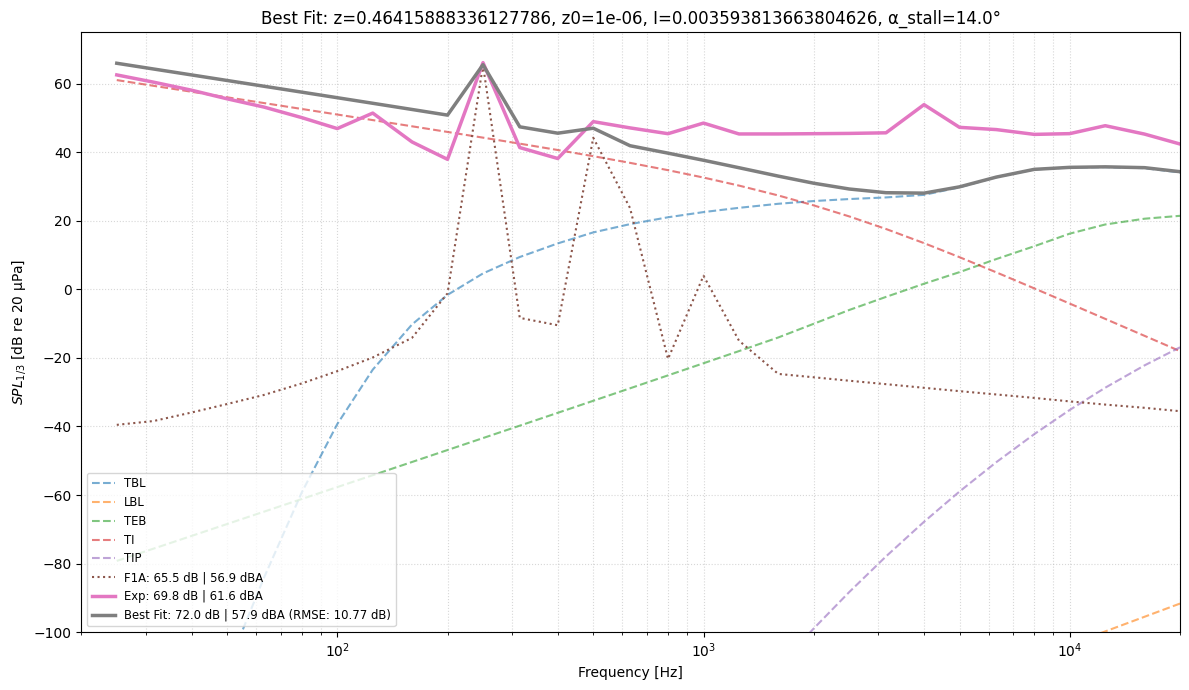

In [24]:
# Plot the best combination
plt.figure(figsize=(12, 7))

# Components
plt.semilogx(third_octave_freqs, bpm.SPL_TBL, '--', alpha=0.6, label='TBL')
plt.semilogx(third_octave_freqs, bpm.SPL_LBL, '--', alpha=0.6, label='LBL')
plt.semilogx(third_octave_freqs, bpm.SPL_TEB, '--', alpha=0.6, label='TEB')
plt.semilogx(third_octave_freqs, bpm.SPL_TI, '--', alpha=0.6, label='TI')
plt.semilogx(third_octave_freqs, bpm.SPL_TIP, '--', alpha=0.6, label='TIP')
plt.semilogx(third_octave_freqs, F1A_spl_3oct, ':', label=f'F1A: {ospl_f1a:.1f} dB | {oaspl_f1a:.1f} dBA')

# Main Comparison Lines
ospl_best = calc_oaspl(best_L_total, third_octave_freqs, weighted=False)
oaspl_best = calc_oaspl(best_L_total, third_octave_freqs, weighted=True)

plt.semilogx(third_octave_freqs, exp_spl_3oct, '-', linewidth=2.5, 
             label=f'Exp: {ospl_exp:.1f} dB | {oaspl_exp:.1f} dBA')
plt.semilogx(third_octave_freqs, best_L_total, '-', linewidth=2.5, 
             label=f'Best Fit: {ospl_best:.1f} dB | {oaspl_best:.1f} dBA (RMSE: {best_error:.2f} dB)')

plt.xlabel('Frequency [Hz]')
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend(loc='lower left', fontsize='small', frameon=True)
plt.xlim(20, 20000)
plt.ylim(-100, 75)
plt.title(f"Best Fit: z={best_params['z']}, z0={best_params['z0']}, I={best_params['I']}, α_stall={best_params['alpha_stall']}°")
plt.tight_layout()
plt.show()